<a href="https://colab.research.google.com/github/eniompw/microgpt-tinystories/blob/main/microgpt-colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MicroGPT — PyTorch (Colab T4 GPU)

The most atomic way to train and run inference for a GPT in pure PyTorch.
Based on [@karpathy](https://github.com/karpathy)'s microgpt.

> **Runtime:** Go to **Runtime → Change runtime type → T4 GPU** before running.

## 1. GPU Setup and Library Imports

In [14]:
import os
import random
import json
import torch
import torch.nn.functional as F

# Reproducibility
random.seed(42)
torch.manual_seed(42)

# Device setup — will use T4 GPU on Colab
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB


## 2. Dataset Download and Preparation

In [15]:
import urllib.request

if not os.path.exists('input.txt'):
    print("Downloading TinyStories dataset from HuggingFace...")
    stories = []
    base_url = 'https://datasets-server.huggingface.co/rows?dataset=karpathy/tinystories-gpt4-clean&config=default&split=train'
    for offset in range(20000, 21000, 100):  # rows 20000+ are the train split
        url = f'{base_url}&offset={offset}&limit=100'
        with urllib.request.urlopen(url) as response:
            data = json.loads(response.read())
        for item in data['rows']:
            stories.append(item['row']['text'])
        print(f"  fetched {len(stories)} stories...", end='\r')
    print()
    with open('input.txt', 'w') as f:
        for story in stories:
            f.write(json.dumps(story) + '\n')
    print("Saved to input.txt")
else:
    print("input.txt already exists, skipping download.")

docs = [json.loads(line) for line in open('input.txt') if line.strip()]
random.shuffle(docs)
print(f"num docs: {len(docs)}")
print(f"sample doc: {docs[0][:120]}...")

input.txt already exists, skipping download.
num docs: 1000
sample doc: Once upon a time, in a small house, there lived a brave little girl named Lucy. She loved to help her mom cook in the ki...


## 3. Tokenizer Setup

In [16]:
# Character-level vocabulary — all 74 chars present in the dataset
uchars = sorted('\n !"$\',-.' + '0123456789:;?' + 'ABCDEFGHIJKLMNOPQRSTUVWXYZ' + 'abcdefghijklmnopqrstuvwxyz')
BOS = len(uchars)          # special Beginning-of-Sequence token id
vocab_size = len(uchars) + 1
print(f"vocab size: {vocab_size}")
print(f"BOS token id: {BOS}")

# Encode / decode helpers
encode = lambda s: [uchars.index(ch) for ch in s]
decode = lambda ids: ''.join(uchars[i] for i in ids)

# Sanity check
sample_text = "Once upon a time"
encoded = encode(sample_text)
decoded = decode(encoded)
print(f"encode('{sample_text}') → {encoded}")
print(f"decode(...)           → '{decoded}'")

vocab size: 75
BOS token id: 74
encode('Once upon a time') → [36, 61, 50, 52, 1, 68, 63, 62, 61, 1, 48, 1, 67, 56, 60, 52]
decode(...)           → 'Once upon a time'


## 4. Model Hyperparameters and Parameter Initialization

In [17]:

# ── Hyperparameters ──────────────────────────────────────────────────────────
# Increase these for better quality at the cost of speed / memory.
n_layer    = 2    # transformer depth
n_embd     = 16   # embedding dimension
block_size = 16   # max context window (tokens)
n_head     = 4    # number of attention heads
head_dim   = n_embd // n_head

# ── Weight initialisation (on GPU) ───────────────────────────────────────────
matrix = lambda nout, nin, std=0.08: torch.randn(nout, nin, device=device) * std

state_dict = {
    'wte':    matrix(vocab_size, n_embd),   # token embeddings
    'wpe':    matrix(block_size, n_embd),   # position embeddings
    'lm_head': matrix(vocab_size, n_embd),  # language model head
}
for i in range(n_layer):
    state_dict[f'layer{i}.attn_wq'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wk'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wv'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wo'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.mlp_fc1'] = matrix(4 * n_embd, n_embd)
    state_dict[f'layer{i}.mlp_fc2'] = matrix(n_embd, 4 * n_embd)

params = list(state_dict.values())
for p in params:
    p.requires_grad_(True)

total_params = sum(p.numel() for p in params)
print(f"num params: {total_params}")
print(f"all tensors on: {next(iter(state_dict.values())).device}")


num params: 8800
all tensors on: cuda:0


## 5. Model Architecture Definition

GPT-2 style transformer with minor tweaks: LayerNorm → RMSNorm, no biases, GeLU → ReLU.

In [18]:
def linear(x, w):
    return w @ x

def softmax(logits):
    return F.softmax(logits, dim=-1)

def rmsnorm(x):
    scale = (x.pow(2).mean() + 1e-5) ** -0.5
    return x * scale

def gpt(token_id, pos_id, keys, values):
    tok_emb = state_dict['wte'][token_id]  # token embedding
    pos_emb = state_dict['wpe'][pos_id]    # position embedding
    x = tok_emb + pos_emb
    x = rmsnorm(x)

    for li in range(n_layer):
        # 1) Multi-head Self-Attention with KV cache
        x_residual = x
        x = rmsnorm(x)
        q = linear(x, state_dict[f'layer{li}.attn_wq'])
        k = linear(x, state_dict[f'layer{li}.attn_wk'])
        v = linear(x, state_dict[f'layer{li}.attn_wv'])
        keys[li].append(k)
        values[li].append(v)
        x_attn = []
        for h in range(n_head):
            hs = h * head_dim
            q_h = q[hs:hs+head_dim]
            k_h = torch.stack([ki[hs:hs+head_dim] for ki in keys[li]])   # (t, head_dim)
            v_h = torch.stack([vi[hs:hs+head_dim] for vi in values[li]]) # (t, head_dim)
            attn_logits = k_h @ q_h / head_dim**0.5                      # (t,)
            attn_weights = softmax(attn_logits)
            head_out = attn_weights @ v_h                                 # (head_dim,)
            x_attn.append(head_out)
        x = linear(torch.cat(x_attn), state_dict[f'layer{li}.attn_wo'])
        x = x + x_residual

        # 2) MLP block
        x_residual = x
        x = rmsnorm(x)
        x = linear(x, state_dict[f'layer{li}.mlp_fc1'])
        x = F.relu(x)
        x = linear(x, state_dict[f'layer{li}.mlp_fc2'])
        x = x + x_residual

    logits = linear(x, state_dict['lm_head'])
    return logits

print("Model functions defined.")

Model functions defined.


## 6. Training Loop

step  100 / 1000 | loss 3.9723
step  200 / 1000 | loss 0.0333
step  300 / 1000 | loss 0.0538
step  400 / 1000 | loss 0.0228
step  500 / 1000 | loss 0.0303
step  600 / 1000 | loss 0.2815
step  700 / 1000 | loss 0.0529
step  800 / 1000 | loss 1.3880
step  900 / 1000 | loss 0.0392
step 1000 / 1000 | loss 0.1998


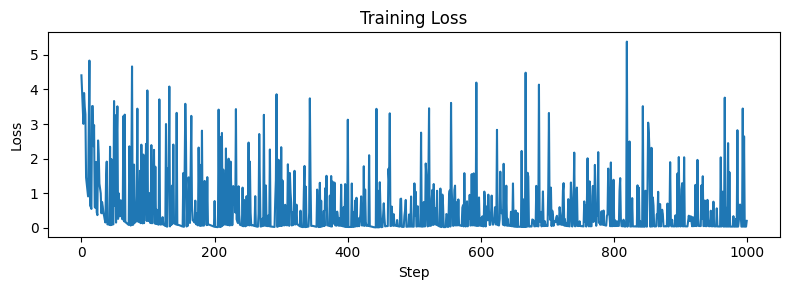

In [19]:

import matplotlib.pyplot as plt

learning_rate = 0.01
num_steps = 1000

optimizer = torch.optim.Adam(params, lr=learning_rate, betas=(0.85, 0.99), eps=1e-8)

loss_history = []

for step in range(num_steps):
    # Tokenize one document, wrap with BOS on both sides
    doc = docs[step % len(docs)]
    tokens = [BOS] + encode(doc) + [BOS]
    n = min(block_size, len(tokens) - 1)

    optimizer.zero_grad()
    keys   = [[] for _ in range(n_layer)]
    values = [[] for _ in range(n_layer)]
    losses = []

    for pos_id in range(n):
        token_id, target_id = tokens[pos_id], tokens[pos_id + 1]
        logits = gpt(token_id, pos_id, keys, values)
        probs  = softmax(logits)
        losses.append(-probs[target_id].log())

    loss = sum(losses) / n
    loss.backward()

    # Linear learning-rate decay
    for g in optimizer.param_groups:
        g['lr'] = learning_rate * (1 - step / num_steps)
    optimizer.step()

    loss_val = loss.item()
    loss_history.append(loss_val)
    if (step + 1) % 100 == 0:
        print(f"step {step+1:4d} / {num_steps} | loss {loss_val:.4f}")

# Plot loss curve
plt.figure(figsize=(8, 3))
plt.plot(loss_history)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.tight_layout()
plt.show()


## 7. Inference and Text Generation

In [20]:

temperature = 0.8   # (0, 1] — lower = more focused, higher = more random
num_samples = 5
max_new_tokens = 200  # generate up to this many tokens per sample

print("--- inference (hallucinated stories) ---\n")
for sample_idx in range(num_samples):
    keys   = [[] for _ in range(n_layer)]
    values = [[] for _ in range(n_layer)]
    token_id = BOS
    sample = []
    with torch.no_grad():
        for pos_id in range(max_new_tokens):
            # clamp position to block_size-1 when generating beyond context window
            pos = min(pos_id, block_size - 1)
            logits   = gpt(token_id, pos, keys, values)
            probs    = softmax(logits / temperature)
            token_id = torch.multinomial(probs, 1).item()
            if token_id == BOS:
                break
            sample.append(uchars[token_id])
    print(f"sample {sample_idx+1}:\n{''.join(sample)}\n")


--- inference (hallucinated stories) ---

sample 1:
One day, a bos nnere a a wa ndandlrere a d ncene nl ag ne a a ne are a a are a dl a ane pe a nd wa a nce ad a a ncend atl cere d ane wal cerere nd d ad ly ere wa na a a nennce nl ne as nd and as d a a

sample 2:
Once upon a timenananancererencererennnncerenncerere a a a tl a aneretl a tl and arererere anncend anere a nererg atl ancere a a tl arerererere anerend anre arerere a a tl a ancerere ttnd arerencere a

sample 3:
One day, a littllllll a llretl llly nl ally aly llly wly atll wlls wly nl lly nerereretlre berls lonl lrerl arly l arererererererly plarerarerce areretlLlle ll anl a a a a nlre watly ly a ane as beren

sample 4:
One day, a littll bennly ll al ares lls lerg ly wa nnlre lly dl annbely al nd anere be atly atll wnnd ncerely are a tl ly was are ncereretll s arl nd as as are l he as ly ndlcerererere as a ara nd a a

sample 5:
Once upon a timererenantll umere tl tlmence anerererererere l and anerere a antl amereretl ane arere